# Quickstart — Hyperiax in five minutes

Hyperiax lets you write tree message-passing algorithms in JAX. The whole user-facing API has four pieces:

| Piece | What it is |
|---|---|
| **`Topology`** | The static shape of the tree (who's whose parent). |
| **`Tree`** | `Topology` + a typed dict of per-node arrays. Immutable. Registered as a JAX pytree, so it rides through `jax.jit` / `jax.lax.scan` / `jax.grad` cleanly. |
| **`@hx.up` / `@hx.down`** | Decorators that turn a small Python function into a leaf→root or root→leaf sweep. |
| **Views** | Inside a sweep, you read data through `node.value`, `parent.value`, `children.value.mean(0)`. |

This notebook walks through all four. By the end you will have built a tree, run an up-sweep and a down-sweep, and verified that sweeps compose with `jax.jit`, `jax.lax.scan`, and `jax.grad`.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx

## 1. Build a topology

A `Topology` is a parent-pointer array plus a bunch of precomputed dispatch metadata. The only convention you need to remember:

- Nodes are stored in **BFS order**: the root is node `0`, and `parents[i] < i` for every other node.
- The root is its own parent (`parents[0] == 0`).

For perfectly symmetric trees there is a convenience constructor. We'll use a binary tree of height 3 — that's $1+2+4+8 = 15$ nodes.

In [2]:
topo = hx.symmetric_topology(depth=3, degree=2)

print(topo)
print(f"  size:         {topo.size}")
print(f"  depth:        {topo.depth}")
print(f"  num leaves:   {int(topo.is_leaf.sum())}")
print(f"  equal_degree: {topo.equal_degree}")
print(f"  parents:      {topo.parents.tolist()}")

Topology(size=15, depth=3, equal_degree=True, max_degree=2)
  size:         15
  depth:        3
  num leaves:   8
  equal_degree: True
  parents:      [0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]


A tiny matplotlib helper so we can see what's going on. Reuse this cell whenever you want to draw a tree.

> `topo.parents`, `topo.level_starts`, `topo.is_leaf`, ... are all `numpy` arrays — the topology lives in numpy-land so it can ride through `jax.jit` as static auxiliary data.

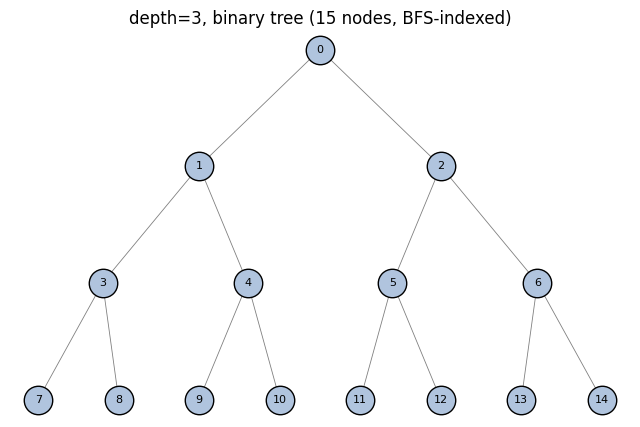

In [3]:
def plot_tree(topo, values=None, ax=None, title=None, cmap='viridis', vmin=None, vmax=None):
    """Top-down layered layout. Pass `values` (shape (N,)) to color nodes."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    pos = np.zeros((topo.size, 2))
    for d in range(topo.depth + 1):
        lo, hi = int(topo.level_starts[d]), int(topo.level_starts[d + 1])
        n = hi - lo
        if n == 1:
            pos[lo:hi, 0] = 0.5
        else:
            pos[lo:hi, 0] = np.linspace(0, 1, n + 2)[1:-1]
        pos[lo:hi, 1] = -d
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0]], [pos[p, 1], pos[i, 1]],
                'k-', lw=0.6, alpha=0.5, zorder=1)
    if values is None:
        ax.scatter(pos[:, 0], pos[:, 1], s=420, c='lightsteelblue',
                   edgecolor='k', zorder=3)
        for i in range(topo.size):
            ax.text(pos[i, 0], pos[i, 1], str(i), ha='center', va='center', fontsize=8)
    else:
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=420, c=np.asarray(values),
                        edgecolor='k', cmap=cmap, vmin=vmin, vmax=vmax, zorder=3)
        plt.colorbar(sc, ax=ax, label='value', shrink=0.8)
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    return ax

plot_tree(topo, title=f"depth={topo.depth}, binary tree ({topo.size} nodes, BFS-indexed)")
plt.show()

## 2. Declare a schema, allocate a `Tree`

A `Tree` is `Topology` + a `dict[str, jax.Array]` whose keys are fixed by a **schema**. You declare what fields exist up front:

```python
Tree.empty(topo, {'value': trailing_shape, ...})
```

Each field has a `(trailing_shape, dtype)` spec — `()` for a scalar field, `(2,)` for a 2-vector field, `(n, n)` for a matrix field, and so on. The leading axis is always the number of nodes; the schema only declares the trailing part.

> **Why declare it up front?** The schema is part of the pytree's static aux data. Adding fields later via `tree.update(...)` changes the pytree structure and invalidates `jit` caches keyed on the old shape. Inside a sweep pipeline you almost always know all your fields at construction time.

In [4]:
tree = hx.Tree.empty(topo, {'value': ()})
print(tree)
print("Initial values (zeros for every node):")
print(tree.value)
print("Allocate shape (leading dimension is the number of nodes):")
print(tree.value.shape)

Tree(size=15, fields={value: ()})
Initial values (zeros for every node):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Allocate shape (leading dimension is the number of nodes):
(15,)


## 3. Seed the leaves

Trees are immutable. Every "mutator" — `set`, `at[...].set/add/...`, `update`, `drop` — returns a *new* `Tree`. This is what lets us put the whole computation inside `jax.jit`.

`tree.at[mask_or_indices].set(field=values)` is the JAX-style scatter — same shape as `arr.at[mask].set(values)`, but takes the field name(s) as keyword arguments. The `at[...]` indexer also exposes `add`, `multiply`, `min`, `max`, and `get`.

Leaves carry 0..7; inner nodes are still zero:
[0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5. 6. 7.]


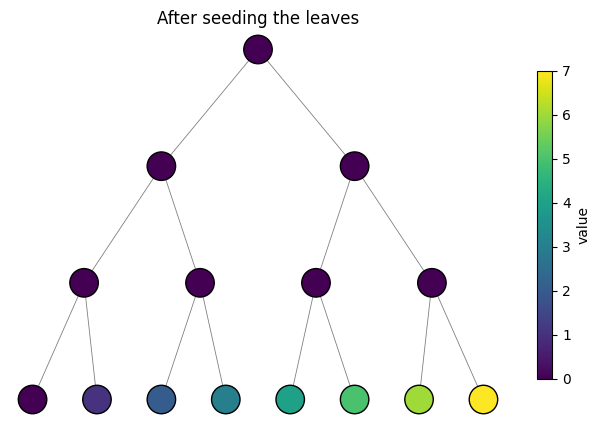

In [5]:
num_leaves = int(topo.is_leaf.sum())                # 8
leaf_obs = jnp.arange(num_leaves, dtype=jnp.float32)

tree = tree.at[topo.is_leaf].set(value=leaf_obs)
print("Leaves carry 0..7; inner nodes are still zero:")
print(tree.value)

plot_tree(topo, tree.value, title="After seeding the leaves")
plt.show()

### Aside: the full `tree.at[...]` interface

`tree.at[indices]` mirrors `jax.numpy.ndarray.at[i]` but lifts it to a multi-field container. The indexer exposes six operations:

| op | what it does | returns |
|---|---|---|
| `.set(field=v, ...)` | scatter-assign | new `Tree` |
| `.add(field=v, ...)` | scatter-add | new `Tree` |
| `.multiply(field=v, ...)` | scatter-multiply | new `Tree` |
| `.min(field=v, ...)` | elementwise min at indices | new `Tree` |
| `.max(field=v, ...)` | elementwise max at indices | new `Tree` |
| `.get()` | read every field at `indices` | `dict[str, jax.Array]` |

All five write ops accept any number of fields as keyword arguments (one scatter pass per field, all sharing the same `indices`). All of them are pure: the original `tree` is unchanged.

In [6]:
# Build a throwaway two-field tree to show every op on the same indices.
demo = (
    hx.Tree.empty(topo, {'value': (), 'count': ()})
      .at[topo.is_leaf].set(value=leaf_obs, count=jnp.ones(num_leaves))
)
print("seed (leaves only):           ", np.asarray(demo.value))

# .add — bump every leaf by 10
bumped = demo.at[topo.is_leaf].add(value=jnp.full(num_leaves, 10.0))
print(".add(+10) at leaves:          ", np.asarray(bumped.value))

# .multiply — scale every leaf's count by 7 (inner-node counts start at 0,
# multiplying them by 7 would be invisible)
scaled = demo.at[topo.is_leaf].multiply(count=jnp.full(num_leaves, 7.0))
print(".multiply(*7) at leaves.count:", np.asarray(scaled['count']))

# .min / .max — clamp the leaves into [2, 5]
clipped = (
    demo.at[topo.is_leaf].max(value=jnp.full(num_leaves, 2.0))
        .at[topo.is_leaf].min(value=jnp.full(num_leaves, 5.0))
)
print(".max(>=2) then .min(<=5):     ", np.asarray(clipped.value))

# .get — read all fields at a set of indices, returns a plain dict
snapshot = demo.at[topo.is_leaf].get()
print(".get() at leaves keys/shape:  ", {k: v.shape for k, v in snapshot.items()})

# Original is untouched (pure functional updates)
print("original demo.value is intact:", np.asarray(demo.value))

seed (leaves only):            [0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5. 6. 7.]
.add(+10) at leaves:           [ 0.  0.  0.  0.  0.  0.  0. 10. 11. 12. 13. 14. 15. 16. 17.]
.multiply(*7) at leaves.count: [0. 0. 0. 0. 0. 0. 0. 7. 7. 7. 7. 7. 7. 7. 7.]
.max(>=2) then .min(<=5):      [0. 0. 0. 0. 0. 0. 0. 2. 2. 2. 3. 4. 5. 5. 5.]
.get() at leaves keys/shape:   {'count': (8,), 'value': (8,)}
original demo.value is intact: [0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5. 6. 7.]


## 4. An up-sweep: propagate information leaf → root

An up-sweep visits every level from the leaves toward the root. At each non-leaf node, your function receives:

- **`node`** — the node's own fields. Each attribute has shape `(*trailing,)` (one node at a time, courtesy of `jax.vmap` inside the dispatcher).
- **`children`** — the children of this node. For an equal-degree tree, `children.value` is a real JAX array of shape `(k, *trailing)` — slice it, multiply it, sum it like any other array. For unequal-degree trees, the same expression works through a `ChildrenAxis` proxy that dispatches reductions to `jax.ops.segment_*`.
- **`params`** — whatever you pass via `sweep(tree, params=...)` (a dict, an array, anything pytree-shaped).

Your function returns a `dict` whose keys exactly match the `writes=` argument. Each value must have shape `(*trailing,)` — one record per node, no need to keep a per-parent batch axis.

We'll compute the simplest message possible: each non-leaf node = mean of its children.

In [7]:
@hx.up(reads_children=('value',), writes=('value',))
def average_children(node, children, params):
    return {'value': children.value.mean(0)}

tree_after_up = average_children(tree)

print("Root value after up-sweep: ", float(tree_after_up.value[0]))
print("Mean of the leaves:        ", float(leaf_obs.mean()))
print("All node values:\n", np.asarray(tree_after_up.value))

Root value after up-sweep:  3.5
Mean of the leaves:         3.5
All node values:
 [3.5 1.5 5.5 0.5 2.5 4.5 6.5 0.  1.  2.  3.  4.  5.  6.  7. ]


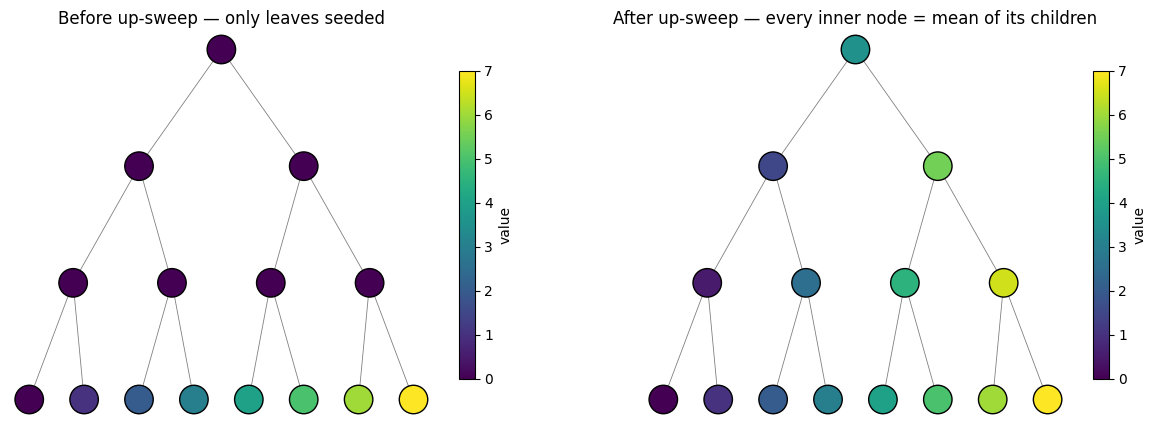

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
vmin, vmax = 0.0, float(num_leaves - 1)
plot_tree(topo, tree.value, ax=axes[0],
          title="Before up-sweep — only leaves seeded", vmin=vmin, vmax=vmax)
plot_tree(topo, tree_after_up.value, ax=axes[1],
          title="After up-sweep — every inner node = mean of its children",
          vmin=vmin, vmax=vmax)
plt.show()

Two things to notice:

1. `tree` itself is unchanged. `average_children` returned a brand-new `Tree`. This is what lets `jax.jit` see the call as a pure function.
2. We only declared `reads_children=('value',)`. We did **not** declare `reads=` on the node itself, because the function doesn't read it. If you forget to declare a field that you actually read, you'll get a clear `AttributeError` pointing at the missing entry — the dispatcher only hands you the fields you asked for.

## 5. A down-sweep: propagate information root → leaf

The mirror image. Your function receives `(node, parent, params)`; for each non-root node, `parent.value` is a `(*trailing,)` view of that node's parent (already updated by the sweep when it visits the level above).

The **root is not visited** (it has no parent), so you must seed it manually before calling the sweep.

Here we use two fields: a `noise` we'll set per node, and a `value` whose root we'll seed. The sweep then propagates `value = parent.value + noise` down the tree.

Root (kept):        1.0
Children of root:   [1.4671319 1.2957029]
All values:
 [ 1.          1.4671319   1.2957029   1.6206777   1.343099    1.512626
 -0.14517605  2.3765376   2.1420875   2.2532694   0.9586024   2.6524494
  2.9584122   0.9357306  -0.20146927]


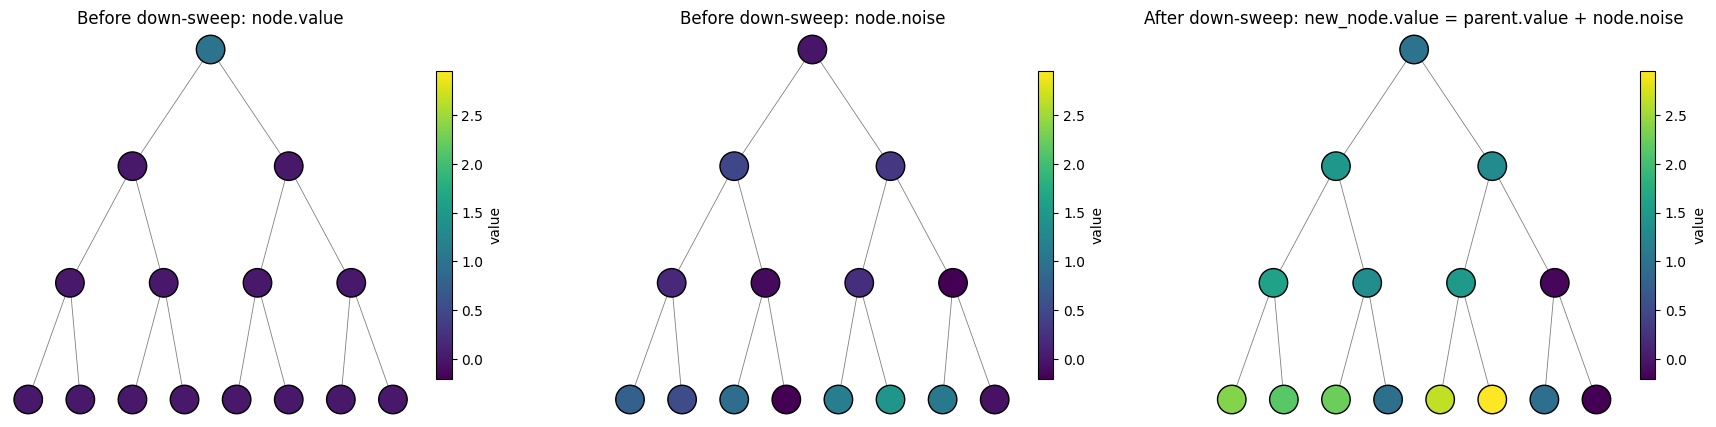

In [9]:
tree_down = hx.Tree.empty(topo, {'value': (), 'noise': ()})

tree_down = tree_down.at[topo.is_root].set(value=jnp.array([1.0]))
tree_down = tree_down.set(noise=jax.random.normal(jax.random.PRNGKey(42), (topo.size,), dtype=jnp.float32))

@hx.down(reads=('noise',), reads_parent=('value',), writes=('value',))
def propagate(node, parent, params):
    return {'value': parent.value + node.noise}

tree_down_done = propagate(tree_down)

print("Root (kept):       ", float(tree_down_done.value[0]))
print("Children of root:  ", np.asarray(tree_down_done.value[1:3]))
print("All values:\n", np.asarray(tree_down_done.value))

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
vmin, vmax = float(tree_down_done.value.min()), float(tree_down_done.value.max())
plot_tree(topo, tree_down.value, ax=axes[0],
          title="Before down-sweep: node.value", vmin=vmin, vmax=vmax)
plot_tree(topo, tree_down.noise, ax=axes[1],
          title="Before down-sweep: node.noise", vmin=vmin, vmax=vmax)
plot_tree(topo, tree_down_done.value, ax=axes[2],
          title="After down-sweep: new_node.value = parent.value + node.noise", vmin=vmin, vmax=vmax)
plt.show()

## 6. Sweeps compose with `jit`, `scan`, `grad`

This is the headline feature of v3. A `Tree` is a JAX pytree (data values are leaves; topology + schema are static aux data), and every sweep is a pure `Tree → Tree`. That means **all of JAX's transformations work directly**.

### 6a. `jax.jit`

Wrap the sweep in `jax.jit`. The first call compiles; subsequent calls on trees with the same structure hit the cache.

In [10]:
print("Unjitted call:")
%timeit _ = average_children(tree)  # JIT-compile the function, but not the call.

jitted_average_children = jax.jit(average_children)
_ = jitted_average_children(tree)  # first-time JIT-compile the function

print("JIT-compiled call:")
# Second call hits the cache — no recompile.
%timeit _ = jitted_average_children(tree)

Unjitted call:
7.55 μs ± 96.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
JIT-compiled call:
5.43 μs ± 23.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### 6b. `jax.lax.scan`

Iterate the same sweep `N` times in one compiled XLA loop. The pitch: the body traces **once**, no per-iteration Python overhead, the whole loop becomes a single device launch.

Two things worth knowing:

1. **Always wrap `jax.lax.scan` in `jax.jit`.** Called eagerly (with no outer jit), `lax.scan` re-traces its body on every invocation — the inner `def body(...)` is a fresh Python closure each call, and that per-call tracing dominates everything else, often making scan look *slower* than a plain Python for-loop. Inside an outer `jit`, the scan op fuses into the surrounding XLA program and per-call overhead disappears.
2. **A Python for-loop *can* be `jit`'d, but it unrolls at trace time** — the compiled program ends up containing `N` copies of the body. Trace and compile time both scale linearly with `N`; at large `N` this becomes impractical (think tens of seconds, then minutes), while `scan` compiles in roughly constant time regardless of `N`. This is why `scan` is the standard idiom for any non-trivial number of iterations.

Two benchmarks below: (a) **runtime** — plain Python for-loop vs scan-in-jit (both `block_until_ready`'d, since JAX dispatches kernels asynchronously and a naive `%timeit` over a for-loop would otherwise only measure dispatch latency); (b) **compile time** — scan-in-jit vs the same Python loop wrapped in `jit` (which forces unrolling). We use `N = 1000` and the unrolled side easily takes minutes.

In [11]:
import time

# Bigger tree so the per-iter body work isn't completely drowned out.
big_topo = hx.symmetric_topology(depth=10, degree=2)              # 2047 nodes
big_tree = (
    hx.Tree.empty(big_topo, {'value': ()})
      .at[big_topo.is_leaf].set(value=jnp.ones(int(big_topo.is_leaf.sum())))
)
print(f"benchmark tree: {big_topo.size} nodes, depth={big_topo.depth}")

N = 1000

def for_loop(tree):                              # Python loop of jit'd calls
    for _ in range(N):
        tree = average_children(tree)
    return tree

@jax.jit
def scan_loop(tree):                             # one trace, one XLA scan op
    def body(t, _):
        return average_children(t), None
    final, _ = jax.lax.scan(body, tree, xs=None, length=N)
    return final

@jax.jit
def unrolled_loop(tree):                         # Python loop, body inlined N×
    for _ in range(N):
        tree = average_children(tree)
    return tree

# --- (a) runtime, post-compile, both block_until_ready ---
_ = jax.block_until_ready(scan_loop(big_tree).value)            # warm scan

print("\n=== runtime (post-compile) ===")
print("Python for-loop of jit'd calls:")
%timeit jax.block_until_ready(for_loop(big_tree).value)
print("scan inside jit:")
%timeit jax.block_until_ready(scan_loop(big_tree).value)

# --- (b) compile time: scan vs unrolled jit ---
def measure_compile(fn, arg):
    """Trace + lower + XLA-compile a fresh jit wrapper, return seconds."""
    t0 = time.perf_counter()
    _ = jax.jit(fn).lower(arg).compile()
    return time.perf_counter() - t0

def _scan_fresh(t):
    def body(s, _): return average_children(s), None
    out, _ = jax.lax.scan(body, t, xs=None, length=N)
    return out

def _unrolled_fresh(t):
    for _ in range(N):
        t = average_children(t)
    return t

print(f"\n=== compile time (N = {N}) ===")
print(f"  scan inside jit ({N} iters, body traced 1×):   {measure_compile(_scan_fresh, big_tree):7.2f} s")
print(f"  unrolled for-loop in jit (body inlined {N}×):  {measure_compile(_unrolled_fresh, big_tree):7.2f} s")

benchmark tree: 2047 nodes, depth=10

=== runtime (post-compile) ===
Python for-loop of jit'd calls:
10.8 ms ± 362 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
scan inside jit:
1.61 ms ± 13.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

=== compile time (N = 1000) ===
  scan inside jit (1000 iters, body traced 1×):      0.06 s


E0520 16:39:43.222145  944354 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__unrolled_fresh for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0520 16:43:46.854518  944352 slow_operation_alarm.cc:140] The operation took 6m3.638498s

********************************
[Compiling module jit__unrolled_fresh for CPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  unrolled for-loop in jit (body inlined 1000×):   373.14 s


### 6c. `jax.grad`

Differentiate end-to-end. Here we treat the leaf observations as the inputs and the root value as the output. With a mean sweep on a height-3 binary tree, each leaf contributes $1/8$ to the root.

In [12]:
def root_from_leaves(leaf_vals):
    t = hx.Tree.empty(topo, {'value': ()})
    t = t.at[topo.is_leaf].set(value=leaf_vals)
    return average_children(t).value[0]

grads = jax.grad(root_from_leaves)(leaf_obs)
print("d(root) / d(leaves) =", np.asarray(grads))
print("expected: 1/8 for each of the 8 leaves =", 1.0 / num_leaves)

d(root) / d(leaves) = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
expected: 1/8 for each of the 8 leaves = 0.125


## Recap & next steps

You've now seen the entire core API:

- `hx.symmetric_topology(height, degree)` (and `hx.from_parents(parents)` for arbitrary topologies)
- `hx.Tree.empty(topo, schema)`, `tree.set(...)`, `tree.at[mask].set(...)`
- `tree.value` for field access (or `tree['value']` when the field name is a dynamic string or collides with a reserved name like `size`)
- `@hx.up(reads_children=, writes=)` with `(node, children, params) -> dict`
- `@hx.down(reads_parent=, writes=)` with `(node, parent, params) -> dict`
- `node.value`, `children.value.mean(0)`, `parent.value` inside a sweep
- Sweeps compose with `jax.jit`, `jax.lax.scan`, `jax.grad` directly

Where to go next:

- **`02_writing_sweeps.ipynb`** — go deeper: equal vs unequal degree trees, the `reads / reads_children / reads_parent / writes` declaration model, custom reductions on the children axis, common patterns (subtree sizes, max depth, weighted means, belief propagation).
- **`03_phylo_mean.ipynb`** — read a real Newick tree, run the `phylo_mean` prebuilt on it.
- **`04_phylo_bayesian.ipynb`** — upgrade the point estimate to a full Bayesian posterior over ancestral states.